# 1. Data Understanding

Bước này giúp chúng ta có cái nhìn tổng thể đầu tiên về cấu trúc và nội dung của bộ dữ liệu.

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1.1 Đọc dữ liệu (Sử dụng bộ dữ liệu có sẵn trong seaborn để thuận tiện)
df = sns.load_dataset('titanic')

# Kiểm tra số dòng, số cột
print(f"Kích thước dữ liệu: {df.shape}")

# Kiểm tra tên các cột và kiểu dữ liệu
print("\nThông tin bộ dữ liệu:")
display(df.info())

# Xem dữ liệu đầu (head)
print("\n5 dòng đầu tiên:")
display(df.head())

# Xem dữ liệu cuối (tail)
print("\n5 dòng cuối cùng:")
display(df.tail())

# Lấy mẫu ngẫu nhiên (sample)
print("\n3 dòng ngẫu nhiên:")
display(df.sample(3))

Kích thước dữ liệu: (891, 15)

Thông tin bộ dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None


5 dòng đầu tiên:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



5 dòng cuối cùng:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True



3 dòng ngẫu nhiên:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
134,0,2,male,25.0,0,0,13.0,S,Second,man,True,NaN,Southampton,no,True
757,0,2,male,18.0,0,0,11.5,S,Second,man,True,NaN,Southampton,no,True
748,0,1,male,19.0,1,0,53.1,S,First,man,True,D,Southampton,no,False


In [ ]:
import seaborn as sns
import pandas as pd

# Tải lại dữ liệu nếu cần thiết
df = sns.load_dataset('titanic')

# Kiểm tra độ tuổi của nhóm 'child'
child_data = df[df['who'] == 'child']['age']
max_child_age = child_data.max()
min_child_age = child_data.min()

print(f"Nhóm 'child' có độ tuổi từ {min_child_age} đến {max_child_age} tuổi.")
print(f"Số lượng trẻ em: {len(child_data)}")

Nhóm 'child' có độ tuổi từ 0.42 đến 15.0 tuổi.
Số lượng trẻ em: 83


## 1.2 Hiểu ý nghĩa dữ liệu

- **Target**: `survived` (0 = Không sống sót, 1 = Sống sót).
- **Features quan trọng**:
    - `pclass`: Hạng vé (1, 2, 3).
    - `sex`: Giới tính.
    - `age`: Tuổi.
    - `sibsp`: Số anh chị em/vợ chồng đi cùng.
    - `parch`: Số cha mẹ/con cái đi cùng.
    - `fare`: Giá vé.
    - `embarked`: Cổng lên tàu (C, Q, S).
    - `who`: Phân loại (man, woman, child).
    - `adult_male`: Có phải đàn ông trưởng thành không (True/False).
    - `deck`: Boong tàu (vị trí phòng)chữ đầu tiên của số phòng .
    - `embark_town`: Tên thành phố lên tàu.
    - `alive`: Trạng thái sống sót (yes/no - trùng lặp với survived).
    - `alone`: Đi một mình hay không.

In [ ]:
# Phân loại biến
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Biến số (Numeric): {numeric_features}")
print(f"Biến phân loại (Categorical): {categorical_features}")

Biến số (Numeric): ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Biến phân loại (Categorical): ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


# 2. Data Quality

Kiểm tra sự sạch sẽ của dữ liệu để đưa ra chiến lược xử lý phù hợp.

Báo cáo giá trị thiếu:


,Total Missing,Percentage (%)
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


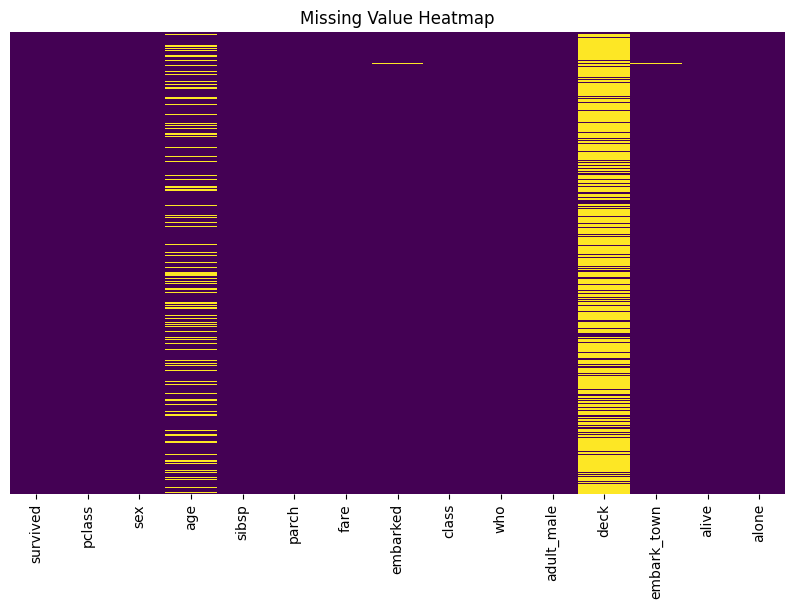

In [ ]:
# 2.1 Missing Values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Total Missing': missing_data,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

print("Báo cáo giá trị thiếu:")
display(missing_report[missing_report['Total Missing'] > 0])

# Vẽ Missing Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

In [ ]:
# 2.2 Duplicate Records
duplicate_count = df.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp: {duplicate_count}")

# Xem các dòng trùng lặp đầu tiên nếu có
if duplicate_count > 0:
    display(df[df.duplicated()].head())

# 2.3 Invalid Values
print("\nKiểm tra giá trị không hợp lệ:")
print(f"Số dòng có Age < 0: {(df['age'] < 0).sum()}")
print(f"Số dòng có Fare < 0: {(df['fare'] < 0).sum()}")
print(f"Các giá trị duy nhất trong Pclass: {df['pclass'].unique()}")
print(f"Các giá trị duy nhất trong Embarked: {df['embarked'].unique()}")

Số lượng bản ghi trùng lặp: 107


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Kiểm tra giá trị không hợp lệ:
Số dòng có Age < 0: 0
Số dòng có Fare < 0: 0
Các giá trị duy nhất trong Pclass: [3 1 2]
Các giá trị duy nhất trong Embarked: ['S' 'C' 'Q' nan]


# 3. Descriptive Statistics & 4. Target Analysis

Phân tích các đặc trưng thống kê của tập dữ liệu và biến mục tiêu.

In [ ]:
# 3.1 Numerical Features Statistics
print("Thống kê mô tả cho các biến số:")
numeric_stats = df[numeric_features].describe().T
numeric_stats['skew'] = df[numeric_features].skew()
numeric_stats['kurtosis'] = df[numeric_features].kurt()
display(numeric_stats)

# 3.2 Categorical Features Statistics
print("\nThống kê mô tả cho các biến phân loại:")
display(df[categorical_features].describe().T)

Thống kê mô tả cho các biến số:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000,0.478523,-1.775005
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000,-0.630548,-1.280015
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000,0.389108,0.178274
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000,3.695352,17.880420
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000,2.749117,9.778125
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292,4.787317,33.398141



Thống kê mô tả cho các biến phân loại:


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


count: Tổng số giá trị không bị thiếu.
unique: Số lượng các nhóm (nhãn) khác nhau trong cột.
top: Giá trị xuất hiện thường xuyên nhất.
freq: Tần suất xuất hiện của giá trị 'top' đó.

/tmp/ipykernel_1354/1260792305.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', palette='viridis')


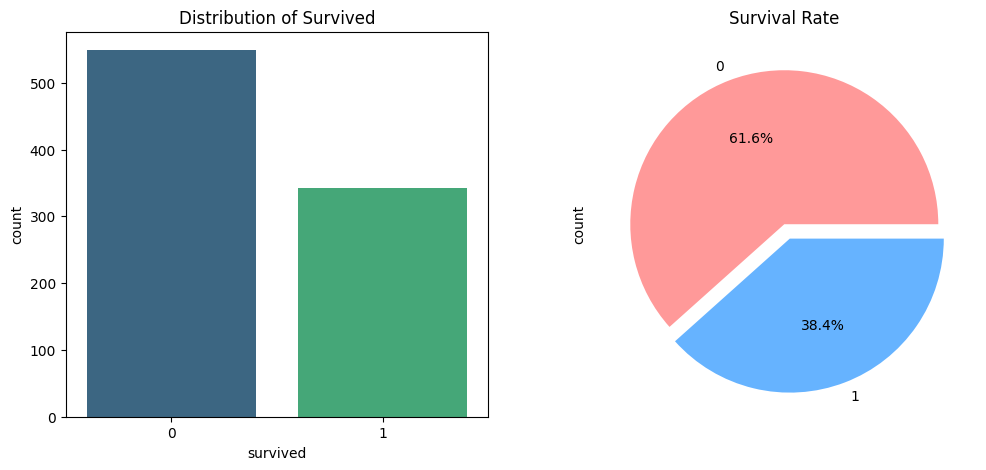

Tỷ lệ sống sót trung bình (Baseline Accuracy): 38.38%


In [ ]:
# 4. Target Analysis (Survived)
plt.figure(figsize=(12, 5))

# Biểu đồ đếm số lượng
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='survived', palette='viridis')
plt.title('Distribution of Survived')

# Biểu đồ tròn %
plt.subplot(1, 2, 2)
df['survived'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=[0, 0.1])
plt.title('Survival Rate')

plt.show()

survival_rate = df['survived'].mean() * 100
print(f"Tỷ lệ sống sót trung bình (Baseline Accuracy): {survival_rate:.2f}%")

# 5. Univariate Analysis

Phân tích phân phối của từng biến độc lập.các biến số

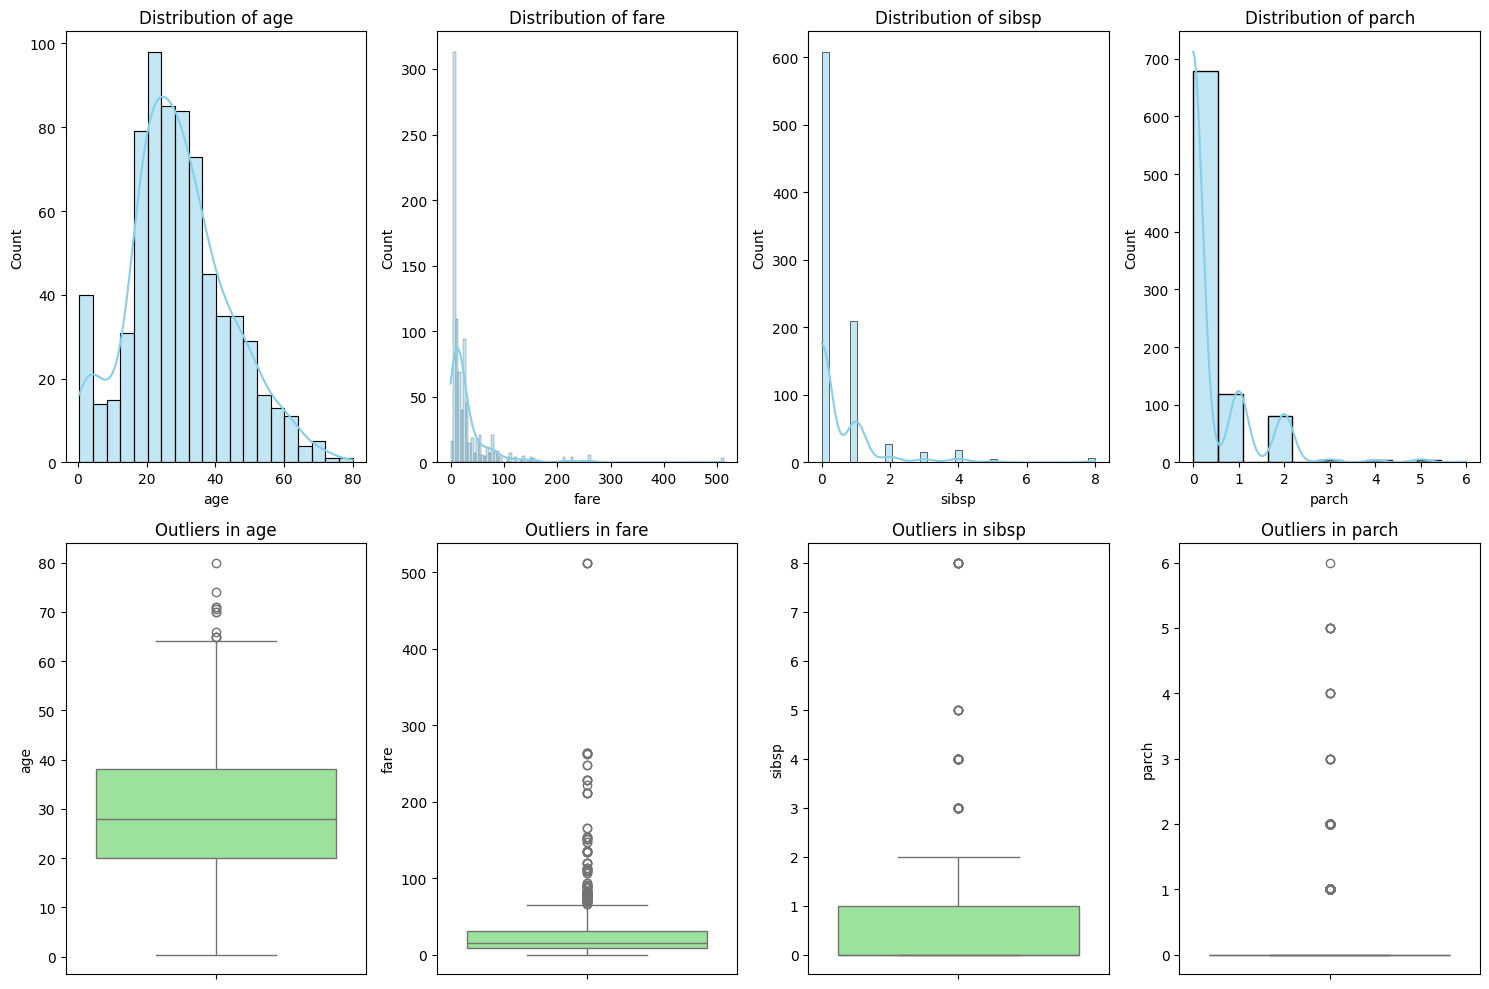

In [ ]:
# 5.1 Numerical Univariate Analysis
num_cols = ['age', 'fare', 'sibsp', 'parch']
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    # Histogram + KDE
    plt.subplot(2, 4, i+1)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

    # Boxplot
    plt.subplot(2, 4, i+5)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

phân tích các biến phân loại

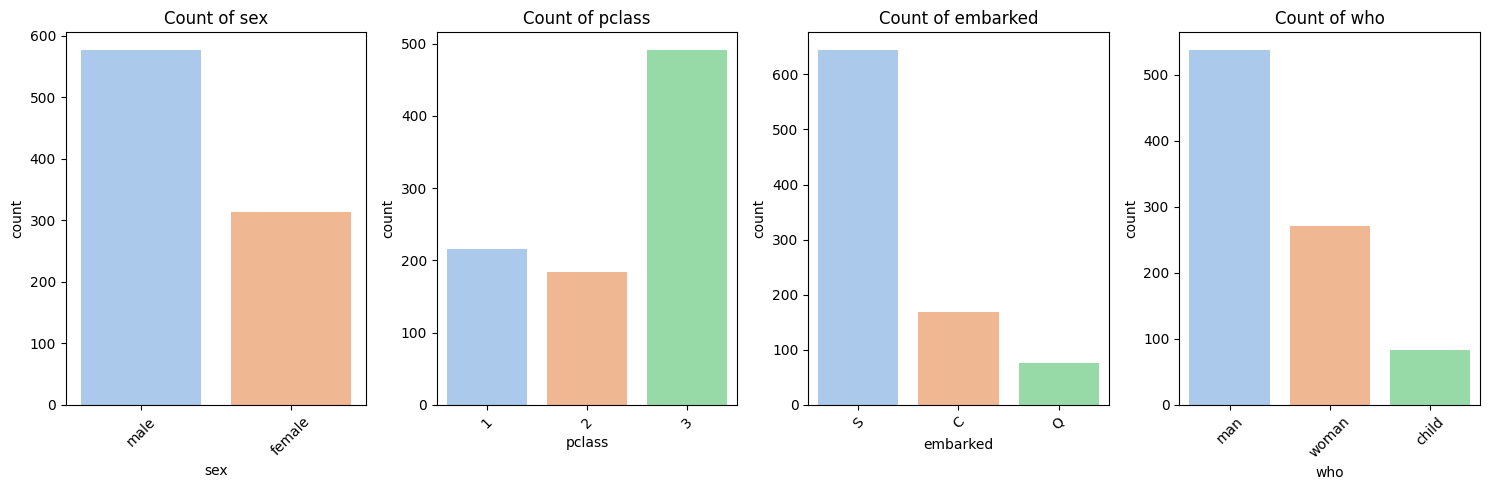

In [ ]:
# 5.2 Categorical Univariate Analysis
cat_cols = ['sex', 'pclass', 'embarked', 'who']
plt.figure(figsize=(15, 5))

for i, col in enumerate(cat_cols):
    plt.subplot(1, 4, i+1)
    sns.countplot(data=df, x=col, palette='pastel', hue=col, legend=False)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 6. Bivariate Analysis

Phân tích mối quan hệ giữa các biến, đặc biệt là với biến mục tiêu `survived`.

/tmp/ipykernel_1354/2329894682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=var, y='survived', palette='muted')
/tmp/ipykernel_1354/2329894682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=var, y='survived', palette='muted')
/tmp/ipykernel_1354/2329894682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=var, y='survived', palette='muted')
/tmp/ipykernel_1354/2329894682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

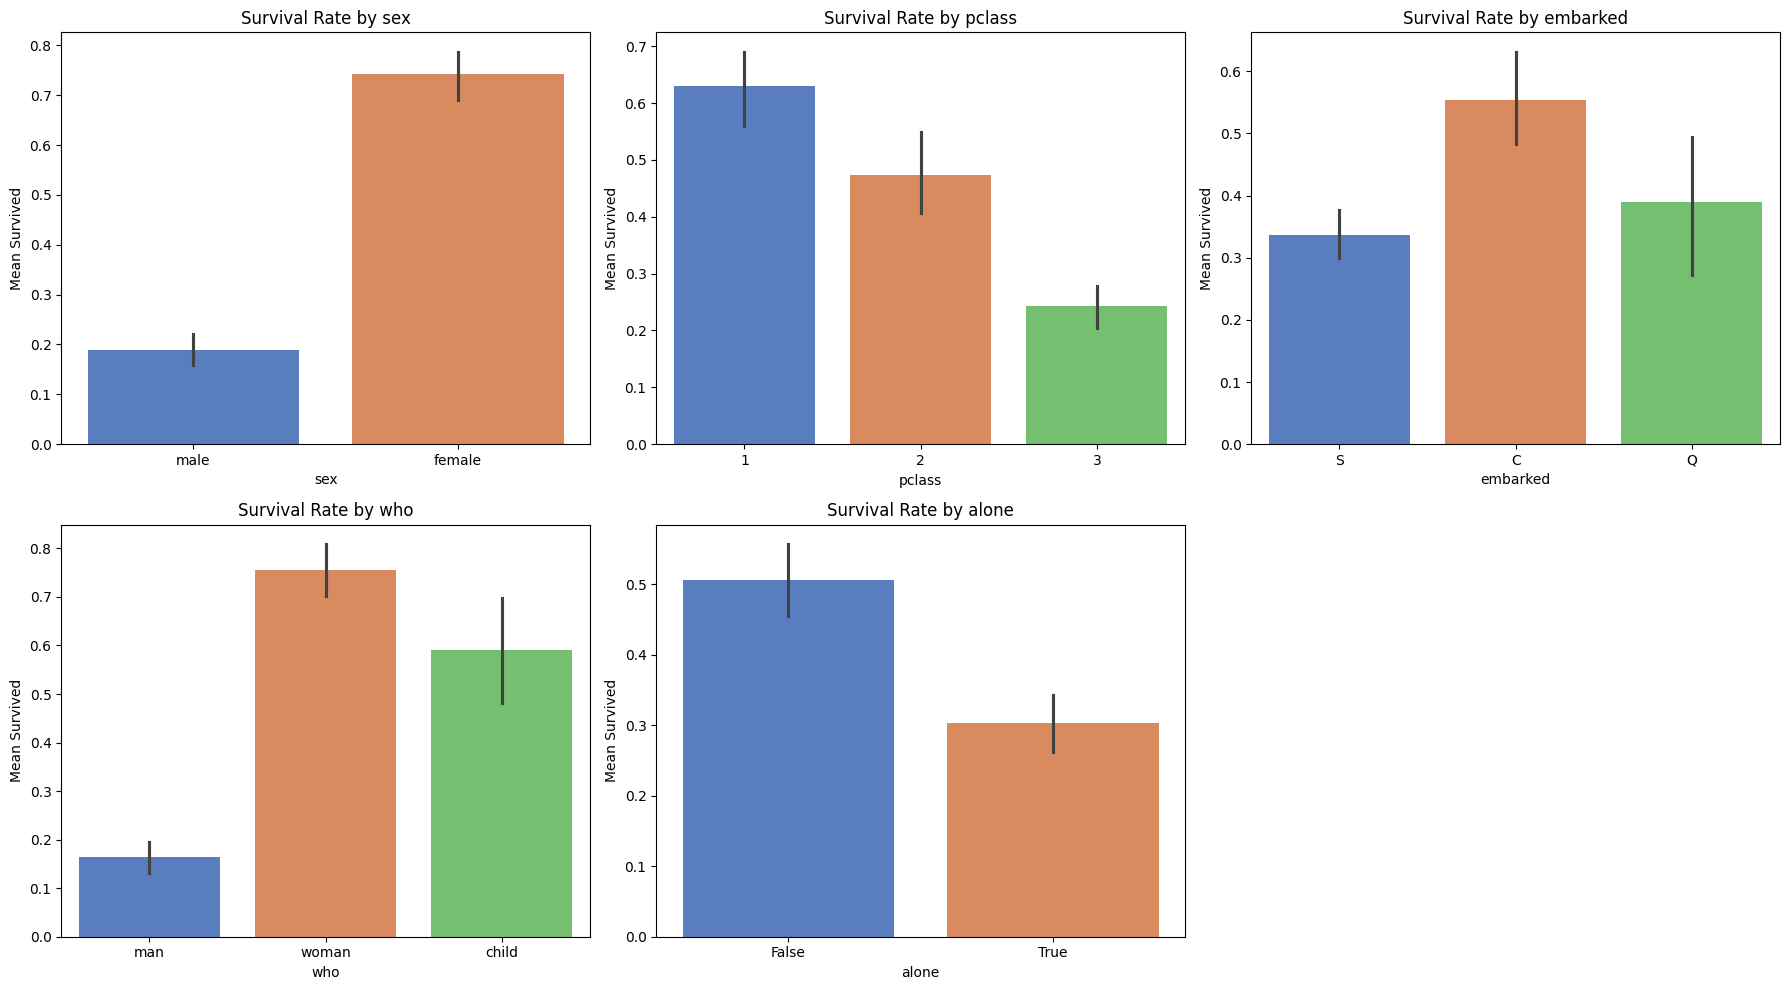

In [ ]:
# 6.1 Target vs Categorical Features
cat_vars = ['sex', 'pclass', 'embarked', 'who', 'alone']
plt.figure(figsize=(18, 10))

for i, var in enumerate(cat_vars):
    plt.subplot(2, 3, i+1)
    sns.barplot(data=df, x=var, y='survived', palette='muted')
    plt.title(f'Survival Rate by {var}')
    plt.ylabel('Mean Survived')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1354/637870220.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['survived'] == 0], x='age', label='Not Survived', shade=True, color='red')
/tmp/ipykernel_1354/637870220.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['survived'] == 1], x='age', label='Survived', shade=True, color='green')
/tmp/ipykernel_1354/637870220.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='survived', y='fare', palette='Set2')


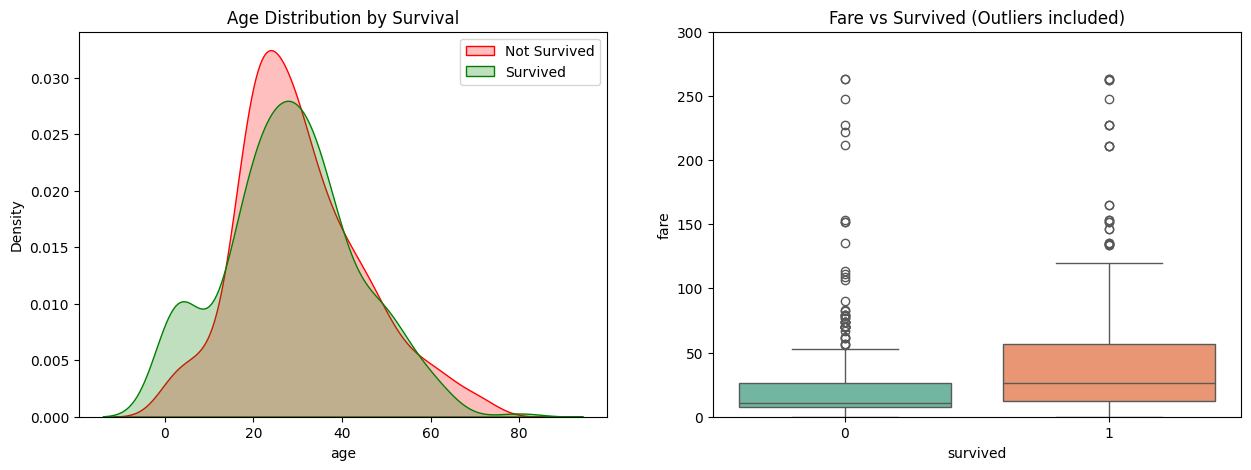

In [ ]:
# 6.2 Target vs Numerical Features
plt.figure(figsize=(15, 5))

# Age vs Survived
plt.subplot(1, 2, 1)
sns.kdeplot(data=df[df['survived'] == 0], x='age', label='Not Survived', shade=True, color='red')
sns.kdeplot(data=df[df['survived'] == 1], x='age', label='Survived', shade=True, color='green')
plt.title('Age Distribution by Survival')
plt.legend()

# Fare vs Survived
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='survived', y='fare', palette='Set2')
plt.title('Fare vs Survived (Outliers included)')
plt.ylim(0, 300) # Giới hạn để dễ quan sát hơn

plt.show()

# 7. Multivariate Analysis & 8. Statistical Analysis

Khám phá sự tương tác phức tạp giữa nhiều biến và kiểm định giả thuyết.

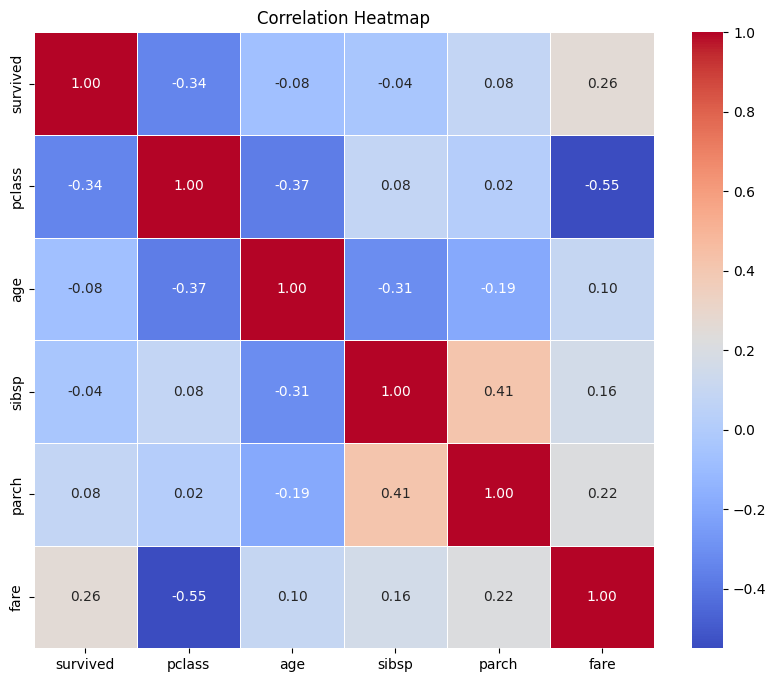

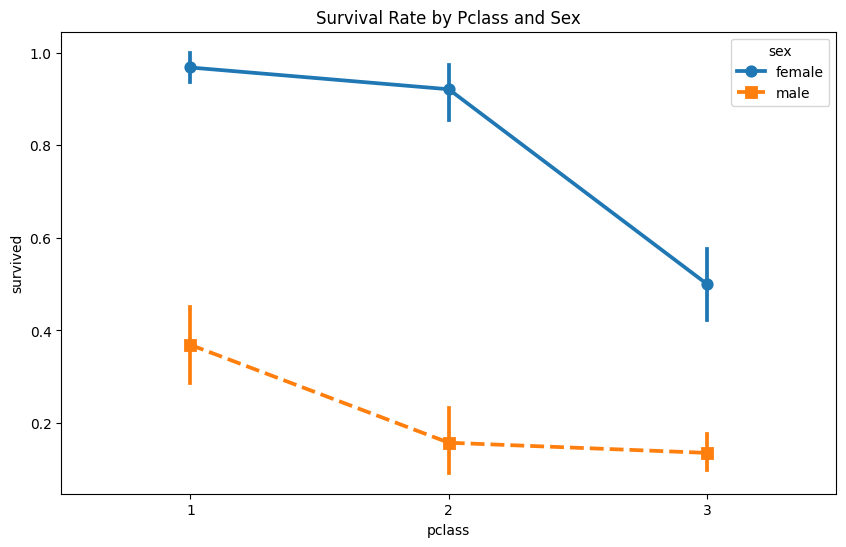

In [ ]:
# 7.1 Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 7.2 Multi-variable Analysis: Sex x Pclass -> Survival
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='pclass', y='survived', hue='sex', markers=['o', 's'], linestyles=['-', '--'])
plt.title('Survival Rate by Pclass and Sex')
plt.show()

Correlation Heatmap (Bản đồ nhiệt tương quan):

df.select_dtypes(include=[np.number]).corr(): Tính toán hệ số tương quan giữa các cột dữ liệu số (như Age, Fare, Survived...). Chỉ số này dao động từ -1 đến 1.
sns.heatmap(..., annot=True): Vẽ bản đồ nhiệt. Màu đỏ đậm thể hiện tương quan thuận mạnh, màu xanh đậm thể hiện tương quan nghịch mạnh. Các con số (annot=True) giúp bạn thấy chính xác mức độ ảnh hưởng (ví dụ: pclass và survived có tương quan âm -0.34, nghĩa là hạng vé càng cao (số 3) thì tỷ lệ sống sót càng thấp).

In [ ]:
from scipy.stats import chi2_contingency

# 8.1 Chi-Square Test (Sex vs Survived)
print("Kiểm định Chi-Square cho Sex và Survived:")
contingency_table = pd.crosstab(df['sex'], df['survived'])
chi2, p, dof, ex = chi2_contingency(contingency_table)
print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("=> Kết luận: Có mối liên hệ có ý nghĩa thống kê giữa Giới tính và Sống sót.")
else:
    print("=> Kết luận: Không đủ bằng chứng về mối liên hệ giữa Giới tính và Sống sót.")

Kiểm định Chi-Square cho Sex và Survived:
Chi-square Statistic: 260.7170
P-value: 1.1974e-58
=> Kết luận: Có mối liên hệ có ý nghĩa thống kê giữa Giới tính và Sống sót.


pd.crosstab(df['sex'], df['survived']): Tạo một bảng tần suất (contingency table) để đếm số lượng người sống sót và không sống sót theo từng giới tính.
chi2_contingency(...): Thực hiện kiểm định Chi-Square (Chi bình phương) trên bảng tần suất đó. Hàm này trả về 4 giá trị, trong đó quan trọng nhất là:
chi2: Giá trị thống kê Chi-square (càng lớn thì sự khác biệt giữa các nhóm càng rõ rệt).
p (P-value): Chỉ số quyết định.
Lập luận P-value:
Trong thống kê, nếu p < 0.05, chúng ta bác bỏ giả thuyết rằng hai biến này độc lập với nhau.
Kết quả thực tế cho ra P-value: 1.1974e-58 (một con số cực kỳ nhỏ, gần như bằng 0).
Kết luận: Vì P-value thấp hơn rất nhiều so với ngưỡng 0.05, mã sẽ in ra kết luận rằng Giới tính có mối liên hệ có ý nghĩa thống kê với khả năng sống sót.

**Giải thích thêm:**
- **Mutual Information (MI)**: Nếu MI = 0, hai biến hoàn toàn độc lập. MI càng cao thì biến đó càng chứa nhiều thông tin giúp dự đoán `survived`.
- Ưu điểm của MI là nó không quan tâm biến đó là số hay phân loại, và nó không bị đánh lừa bởi các mối quan hệ hình cong phức tạp.

In [5]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Đảm bảo các cột Feature Engineering đã tồn tại
if 'family_size' not in df.columns:
    df['family_size'] = df['sibsp'] + df['parch'] + 1
if 'is_alone' not in df.columns:
    df['is_alone'] = (df['family_size'] == 1).astype(int)

# Chuẩn bị dữ liệu và xử lý giá trị thiếu cho Age (nếu có)
X_mi = df[['pclass', 'age', 'fare', 'family_size', 'is_alone']].copy()
X_mi['age'] = X_mi['age'].fillna(X_mi['age'].median())
X_mi['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})
y_mi = df['survived']

# Tính Mutual Information Scores
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_results = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

print("Mutual Information Scores (Càng cao càng có quan hệ mạnh với Survived):")
print(mi_results)

Mutual Information Scores (Càng cao càng có quan hệ mạnh với Survived):
sex_encoded    0.162569
fare           0.134786
pclass         0.052016
family_size    0.048470
is_alone       0.008275
age            0.007137
dtype: float64


# 10. Feature Engineering & 11. Missing Value Strategy

Tạo thêm thông tin từ dữ liệu cũ và quyết định cách xử lý các ô trống.

In [ ]:
# 10.1 Feature Engineering: Family Size & IsAlone
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

# 10.2 Feature Engineering: Fare Binning
df['fare_bin'] = pd.qcut(df['fare'], 4)

print("Các feature mới đã được tạo: family_size, is_alone, fare_bin")
display(df[['family_size', 'is_alone', 'fare_bin']].head())

Các feature mới đã được tạo: family_size, is_alone, fare_bin


,family_size,is_alone,fare_bin
0,2,0,"(-0.001, 7.91]"
1,2,0,"(31.0, 512.329]"
2,1,1,"(7.91, 14.454]"
3,2,0,"(31.0, 512.329]"
4,1,1,"(7.91, 14.454]"


df['fare_bin'] = pd.qcut(df['fare'], 4):

Chia giá vé (fare) thành 4 nhóm bằng nhau về số lượng mẫu phân theo Tứ phân vị.
Thay vì dùng con số cụ thể, việc chia nhóm giúp giảm ảnh hưởng của các giá trị vé cực cao và giúp mô hình xử lý biến số tốt hơn dưới dạng các khoảng giá trị

In [ ]:
# 11.1 Missing Value Strategy
# Điền Age bằng Median theo Sex và Pclass
df['age'] = df['age'].fillna(df.groupby(['sex', 'pclass'])['age'].transform('median'))

# Điền Embarked bằng Mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Drop cột Deck vì thiếu quá nhiều (77%)
df.drop(columns=['deck'], inplace=True)

print("Đã xử lý xong Missing Values. Kiểm tra lại:")
print(df.isnull().sum())

Đã xử lý xong Missing Values. Kiểm tra lại:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
family_size    0
is_alone       0
fare_bin       0
dtype: int64


Tuổi tác thường có sự khác biệt rõ rệt giữa các nhóm. Ví dụ: hành khách ở hạng vé cao (pclass 1) thường có xu hướng lớn tuổi hơn hạng phổ thông, hoặc cơ cấu tuổi giữa nam và nữ có thể khác nhau.
Thay vì dùng một con số trung bình (mean) cho cả tàu, việc dùng trung vị (median) của từng nhóm nhỏ (nhóm theo giới tính và hạng vé) sẽ giúp con số điền vào chính xác và thực tế hơn, tránh bị ảnh hưởng bởi các giá trị ngoại lai (outliers).

Hàm sử dụng: .fillna(df['...'].mode()[0])
Tại sao làm vậy?:
Đây là các biến phân loại (categorical). Với dữ liệu dạng chữ, chúng ta không thể tính trung bình hay trung vị.
Yếu vị (Mode) là giá trị xuất hiện nhiều nhất. Vì chỉ có 2 bản ghi bị thiếu, việc điền bằng cổng phổ biến nhất (thường là 'Southampton' - S) là phương pháp an toàn và ít làm thay đổi bản chất phân phối của dữ liệu nhất.

Khi một cột thiếu quá nhiều (thường là trên 60-70%), bất kỳ phương pháp điền dữ liệu nào (imputation) cũng sẽ tạo ra rất nhiều "nhiễu" (noise) và có thể làm sai lệch mô hình dự báo sau này. Do đó, loại bỏ hoàn toàn là quyết định tốt nhất để giữ cho dữ liệu sạch và đáng tin cậy

# 14. EDA Summary & Deliverables

- **Data Quality**: Đã xử lý 177 giá trị thiếu ở `age` và 2 ở `embarked`. Loại bỏ cột `deck` do thiếu >70%.
- **Feature Analysis**: `sex`, `pclass`, và `fare` là những biến có ảnh hưởng mạnh nhất đến khả năng sống sót.
- **Feature Engineering**: Đã tạo thêm `family_size` và `is_alone` giúp nắm bắt cấu trúc gia đình hành khách.
- **Modeling Readiness**: Dữ liệu đã sạch, không còn giá trị thiếu. Sẵn sàng cho bước Encoding và Scaling.